PROBELM 1: Differentiation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

In [2]:
# (a) differentiate using single precision forward-, central-, and extrapolated-difference algorithms

# functions we want to differentiate

x_list = [0.1, 10]

def f(x):
    x = np.float32(x)
    return np.cos(x)

def g(x):
    x = np.float32(x)
    return np.exp(x)

def f_prime_analytic(x):
    x = np.float32(x)
    return -np.sin(x)

def g_prime_analytic(x):
    x = np.float32(x)
    return np.exp(x)

# our three difference algorithms

def forward_difference(f, x, h):
    x = np.float32(x)
    h = np.float32(h)
    return (f(x+h) - f(x)) / h

def central_difference(f, x, h):
    x = np.float32(x)
    h = np.float32(h)
    return (f(x+h) - f(x-h)) / (np.float32(2)*h)

def extrapolated_difference(f, x, h, n):
    x = np.float32(x)
    h = np.float32(h)
    F = np.zeros((n,n), dtype=np.float32)

    for i in range(n):
        hi = h/np.float32(2**i)
        F[i,0] = central_difference(f, x, hi)

    for j in range(1,n):
        for i in range(j, n):
            F[i,j] = (np.float32(1)/(np.float32(4**j) - np.float32(1))) * (np.float32(4**j) * F[i, j-1] - F[i-1, j-1])

    return F[n-1, n-1]

# relative error (fractional)

def relative_error(approx, exact):
    approx = np.float32(approx)
    exact = np.float32(exact)
    return np.abs((approx - exact) / exact)

In [3]:
# let's test only n=4 for extrapolated difference and h in logspace(-8, -1, 10) first

results_test = []

for x in x_list:

    f_prime_analytical = f_prime_analytic(x)
    g_prime_analytical = g_prime_analytic(x)

    for h in np.logspace(-8, -1, 10):
        f_prime_forward = forward_difference(f, x, h)
        f_prime_central = central_difference(f, x, h)

        error_f_forward = relative_error(f_prime_forward, f_prime_analytical)
        error_f_central = relative_error(f_prime_central, f_prime_analytical)

        g_prime_forward = forward_difference(g, x, h)
        g_prime_central = central_difference(g, x, h)

        error_g_forward = relative_error(g_prime_forward, g_prime_analytical)
        error_g_central = relative_error(g_prime_central, g_prime_analytical)

        f_prime_extrapolated = extrapolated_difference(f, x, h, 4)
        g_prime_extrapolated = extrapolated_difference(g, x, h, 4)

        error_f_extrapolated = relative_error(f_prime_extrapolated, f_prime_analytical)
        error_g_extrapolated = relative_error(g_prime_extrapolated, g_prime_analytical)

        results_test.append({
            "x": x,
            "h": h,
            "f_exact": f_prime_analytical,
            "f_forward": f_prime_forward,
            "f_forward_error": error_f_forward,
            "f_central": f_prime_central,
            "f_central_error": error_f_central,
            "f_extrapolated": f_prime_extrapolated,
            "f_extrapolated_error": error_f_extrapolated,
            "g_exact": g_prime_analytical,
            "g_forward": g_prime_forward,
            "g_forward_error": error_g_forward,
            "g_central": g_prime_central,
            "g_central_error": error_g_central,
            "g_extrapolated": g_prime_extrapolated,
            "g_extrapolated_error": error_g_extrapolated,
        })


results_df_test = pd.DataFrame(results_test)     

In [4]:
results_df_test

,x,h,f_exact,f_forward,f_forward_error,f_central,f_central_error,f_extrapolated,f_extrapolated_error,g_exact,g_forward,g_forward_error,g_central,g_central_error,g_extrapolated,g_extrapolated_error
0,0.1,1.000000e-08,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000e+00,1.105171,0.000000,1.000000,5.960464,4.393251,0.351110,0.682302
1,0.1,5.994843e-08,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000e+00,1.105171,0.000000,1.000000,0.994265,0.100352,9.665242,7.745472
2,0.1,3.593814e-07,-0.099833,-0.165853,0.661302,-0.082927,0.169349,-0.004885,9.510692e-01,1.105171,0.995121,0.099578,0.995121,0.099578,1.002609,0.092802
3,0.1,2.154435e-06,-0.099833,-0.110664,0.108487,-0.096831,0.030073,-0.110669,1.085365e-01,1.105171,1.051309,0.048736,1.078975,0.023703,1.424786,0.289199
4,0.1,1.291550e-05,-0.099833,-0.101529,0.016988,-0.099222,0.006126,-0.114866,1.505724e-01,1.105171,1.098363,0.006160,1.102978,0.001984,1.169688,0.058377
5,0.1,7.742637e-05,-0.099833,-0.100077,0.002441,-0.099692,0.001415,-0.097853,1.983982e-02,1.105171,1.105467,0.000268,1.106236,0.000964,1.100972,0.003799
6,0.1,4.641589e-04,-0.099833,-0.100035,0.002017,-0.099778,0.000556,-0.099532,3.023938e-03,1.105171,1.105390,0.000199,1.105134,0.000034,1.104135,0.000938
7,0.1,2.782559e-03,-0.099833,-0.101213,0.013821,-0.099832,0.000018,-0.099822,1.187365e-04,1.105171,1.106684,0.001369,1.105163,0.000007,1.105143,0.000025
8,0.1,1.668101e-02,-0.099833,-0.108129,0.083092,-0.099830,0.000035,-0.099839,5.216646e-05,1.105171,1.114432,0.008380,1.105221,0.000045,1.105185,0.000013
9,0.1,1.000000e-01,-0.099833,-0.149376,0.496250,-0.099667,0.001667,-0.099834,8.955615e-07,1.105171,1.162318,0.051709,1.107014,0.001667,1.105164,0.000007


In [5]:
# let's test various n and wider range of h as well

results = []

for x in x_list:

    f_prime_analytical = f_prime_analytic(x)
    g_prime_analytical = g_prime_analytic(x)

    for h in np.logspace(-7, 1, 100, dtype = np.float32):
        f_prime_forward = forward_difference(f, x, h)
        f_prime_central = central_difference(f, x, h)

        error_f_forward = relative_error(f_prime_forward, f_prime_analytical)
        error_f_central = relative_error(f_prime_central, f_prime_analytical)

        g_prime_forward = forward_difference(g, x, h)
        g_prime_central = central_difference(g, x, h)

        error_g_forward = relative_error(g_prime_forward, g_prime_analytical)
        error_g_central = relative_error(g_prime_central, g_prime_analytical)

        for n in [2, 3, 4, 5]:
            f_prime_extrapolated = extrapolated_difference(f, x, h, n)
            g_prime_extrapolated = extrapolated_difference(g, x, h, n)

            error_f_extrapolated = relative_error(f_prime_extrapolated, f_prime_analytical)
            error_g_extrapolated = relative_error(g_prime_extrapolated, g_prime_analytical)

            results.append({
                "x": x,
                "h": h,
                "n": n,
                "f_exact": f_prime_analytical,
                "f_forward": f_prime_forward,
                "f_forward_error": error_f_forward,
                "f_central": f_prime_central,
                "f_central_error": error_f_central,
                "f_extrapolated": f_prime_extrapolated,
                "f_extrapolated_error": error_f_extrapolated,
                "g_exact": g_prime_analytical,
                "g_forward": g_prime_forward,
                "g_forward_error": error_g_forward,
                "g_central": g_prime_central,
                "g_central_error": error_g_central,
                "g_extrapolated": g_prime_extrapolated,
                "g_extrapolated_error": error_g_extrapolated,
            })


results_df = pd.DataFrame(results)     

In [6]:
results_df

,x,h,n,f_exact,f_forward,f_forward_error,f_central,f_central_error,f_extrapolated,f_extrapolated_error,g_exact,g_forward,g_forward_error,g_central,g_central_error,g_extrapolated,g_extrapolated_error
0,0.1,1.000000e-07,2,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.788139e+00,0.617975,9.934108e-01,0.101125
1,0.1,1.000000e-07,3,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.788139e+00,0.617975,2.900759e+00,1.624716
2,0.1,1.000000e-07,4,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.788139e+00,0.617975,5.793741e+00,4.242393
3,0.1,1.000000e-07,5,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,1.192093e+00,0.078650,1.788139e+00,0.617975,1.161105e+01,9.506110
4,0.1,1.204504e-07,2,-0.099833,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.105171,9.896965e-01,0.104486,1.484545e+00,0.343272,8.247471e-01,0.253738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,10.0,8.302176e+00,5,0.544021,0.203918,0.625165,0.059055,0.891446,0.544009,0.000022,22026.466797,1.069632e+07,484.612030,5.349484e+06,241.866211,2.202796e+04,0.000068
796,10.0,1.000000e+01,2,0.544021,0.124715,0.770753,-0.029596,1.054402,-0.129248,1.237579,22026.466797,4.851432e+07,2201.546631,2.425826e+07,1100.323242,-7.650238e+06,348.320221
797,10.0,1.000000e+01,3,0.544021,0.124715,0.770753,-0.029596,1.054402,0.230933,0.575507,22026.466797,4.851432e+07,2201.546631,2.425826e+07,1100.323242,4.696022e+05,20.319904
798,10.0,1.000000e+01,4,0.544021,0.124715,0.770753,-0.029596,1.054402,0.531901,0.022279,22026.466797,4.851432e+07,2201.546631,2.425826e+07,1100.323242,1.664121e+04,0.244490


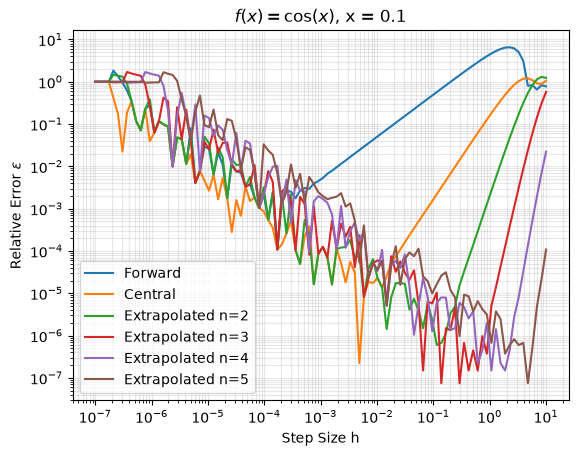


$f(x)=\cos(x)$, x=0.1
forward: h = 1.707e-04, min error = 1.081e-04, digits ~ 3.97
central: h = 4.863e-03, min error = 2.239e-07, digits ~ 6.65
extrapolated n=2: h = 1.150e-01, min error = 5.970e-07, digits ~ 6.22
extrapolated n=3: h = 1.385e-01, min error = 7.463e-08, digits ~ 7.13
extrapolated n=4: h = 1.072e+00, min error = 1.493e-07, digits ~ 6.83
extrapolated n=5: h = 4.751e+00, min error = 7.463e-08, digits ~ 7.13


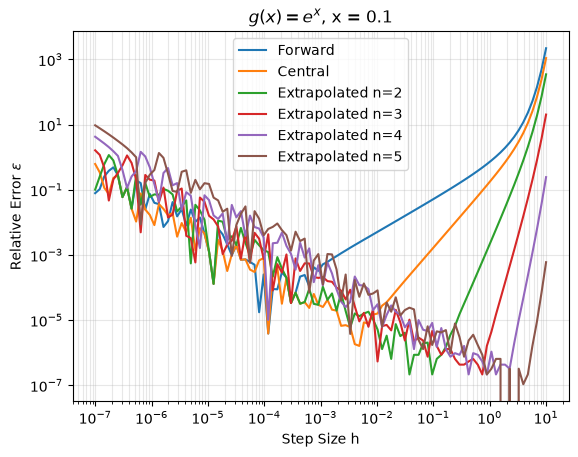


$g(x)=e^x$, x=0.1
forward: h = 1.177e-04, min error = 3.883e-06, digits ~ 5.41
central: h = 4.863e-03, min error = 1.618e-06, digits ~ 5.79
extrapolated n=2: h = 3.765e-02, min error = 2.157e-07, digits ~ 6.67
extrapolated n=3: h = 7.391e-01, min error = 2.157e-07, digits ~ 6.67
extrapolated n=4: h = 4.229e-01, min error = 2.157e-07, digits ~ 6.67
extrapolated n=5: h = 1.874e+00, min error = 0.000e+00, digits ~ inf


/tmp/ipykernel_2802/2609297144.py:45: RuntimeWarning: divide by zero encountered in log10
  print(f"extrapolated n={n}: h = {h_best:.3e}, min error = {err:.3e}, digits ~ {-np.log10(err):.2f}")


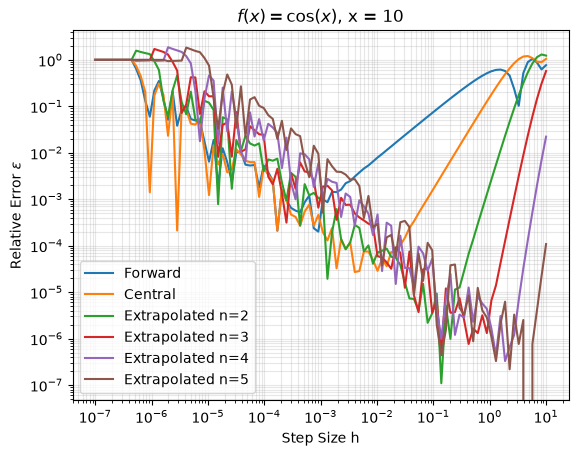


$f(x)=\cos(x)$, x=10
forward: h = 9.112e-04, min error = 2.012e-04, digits ~ 3.70
central: h = 4.037e-03, min error = 2.717e-05, digits ~ 4.57
extrapolated n=2: h = 1.385e-01, min error = 1.096e-07, digits ~ 6.96
extrapolated n=3: h = 1.385e-01, min error = 5.478e-07, digits ~ 6.26
extrapolated n=4: h = 1.874e+00, min error = 3.287e-07, digits ~ 6.48
extrapolated n=5: h = 4.751e+00, min error = 0.000e+00, digits ~ inf


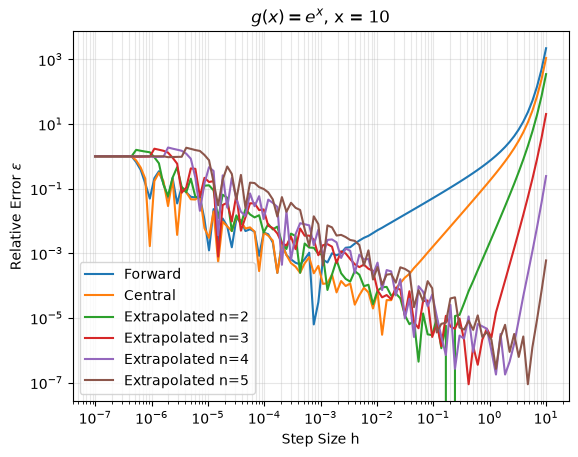


$g(x)=e^x$, x=10
forward: h = 7.565e-04, min error = 6.296e-06, digits ~ 5.20
central: h = 1.233e-02, min error = 3.015e-06, digits ~ 5.52
extrapolated n=2: h = 2.009e-01, min error = 0.000e+00, digits ~ inf
extrapolated n=3: h = 4.229e-01, min error = 8.867e-08, digits ~ 7.05
extrapolated n=4: h = 1.292e+00, min error = 1.773e-07, digits ~ 6.75
extrapolated n=5: h = 4.751e+00, min error = 8.867e-08, digits ~ 7.05


In [7]:
# plotting relative error vs step size (loglog)

for x in x_list:
    df_x = results_df[results_df["x"] == x]
    df_base = df_x[df_x["n"] == 2] # as to avoid repetitive plotting of forward and central

    for func, label in [("f", r"$f(x)=\cos(x)$"), ("g", r"$g(x)=e^x$")]:

        plt.loglog(df_base["h"], df_base[f"{func}_forward_error"], label="Forward")
        plt.loglog(df_base["h"], df_base[f"{func}_central_error"], label="Central")

        for n in [2,3,4,5]:
            df_n = df_x[df_x["n"] == n]
            plt.loglog(df_n["h"], df_n[f"{func}_extrapolated_error"], label=f"Extrapolated n={n}")

        # plt.axvline(x = 10**(-3.5), color='pink', linestyle='--', linewidth=2)
        plt.xlabel("Step Size h")
        plt.ylabel(r"Relative Error $\epsilon$")
        plt.title(f"{label}, x = {x}")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.show()

        print(f"\n{label}, x={x}")

        for method in ["forward", "central"]:
            col = f"{func}_{method}_error"
            idx = df_base[col].idxmin()
            err = df_base.loc[idx, col]
            h_best = df_base.loc[idx, "h"]

            print(
                f"{method}: h = {h_best:.3e}, "
                f"min error = {err:.3e}, "
                f"digits ~ {-np.log10(err):.2f}"
            )

        for n in [2,3,4,5]:
            df_n = df_x[df_x["n"] == n]
            col = f"{func}_extrapolated_error"
            idx = df_n[col].idxmin()
            err = df_n.loc[idx, col]
            h_best = df_n.loc[idx, "h"]

            print(f"extrapolated n={n}: h = {h_best:.3e}, min error = {err:.3e}, digits ~ {-np.log10(err):.2f}")


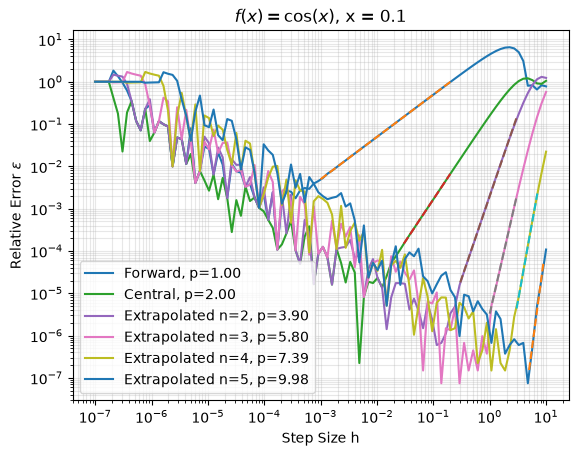

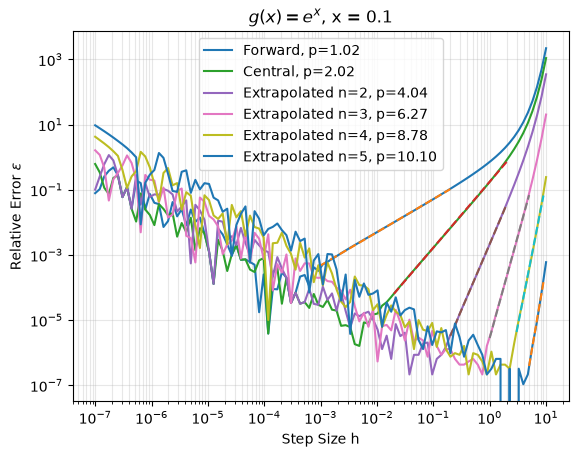

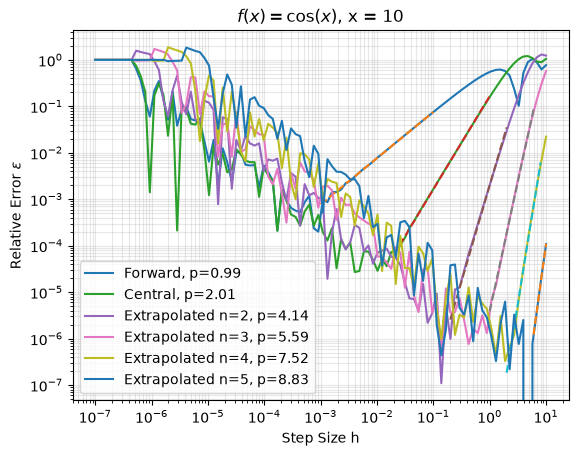

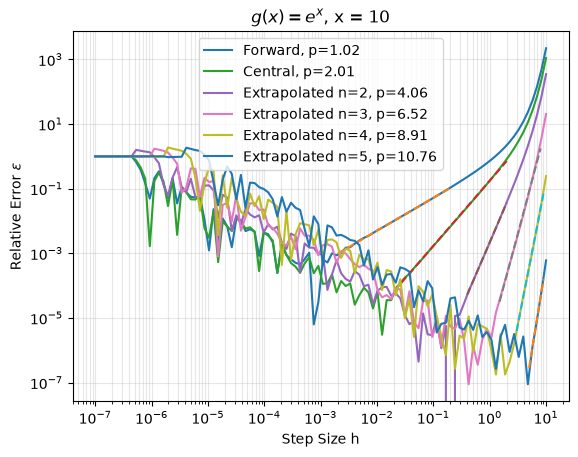

In [8]:
# let's check the scaling of error with h (fitting range in truncation error regime through visual inspection)

# f x = 10

forward_1 = [1e-3, 1e-1]
central_1 = [2e-2, 1]
richardson2_1 = [2e-1, 2]
richardson3_1 = [1,6]
richardson4_1 = [2,8]
richardson5_1 = [6, 10]

# g x = 0.1

forward_2 = [1e-3, 2e-1]
central_2 = [2e-2, 2]
richardson2_2 = [2e-1,2]
richardson3_2 = [1, 5]
richardson4_2 = [3,9]
richardson5_2 = [5, 9]

# f x = 0.1

forward_3 = [1e-3, 2e-1]
central_3 = [3e-2, 2e-1]
richardson2_3 = [3e-1, 3]
richardson3_3 = [1,3]
richardson4_3 = [3, 7]
richardson5_3 = [5, 9]

# g x = 10

forward_4 = [2e-3, 2e-1]
central_4 = [2e-2, 2]
richardson2_4 = [4e-1, 2]
richardson3_4 = [1.5, 8]
richardson4_4 = [3, 9]
richardson5_4 = [5, 9]

fit_ranges = {
    ("f", 10): {
        "forward": forward_1,
        "central": central_1,
        2: richardson2_1,
        3: richardson3_1,
        4: richardson4_1,
        5: richardson5_1,
    },

    ("g", 0.1): {
        "forward": forward_2,
        "central": central_2,
        2: richardson2_2,
        3: richardson3_2,
        4: richardson4_2,
        5: richardson5_2,
    },

    ("f", 0.1): {
        "forward": forward_3,
        "central": central_3,
        2: richardson2_3,
        3: richardson3_3,
        4: richardson4_3,
        5: richardson5_3,
    },

    ("g", 10): {
        "forward": forward_4,
        "central": central_4,
        2: richardson2_4,
        3: richardson3_4,
        4: richardson4_4,
        5: richardson5_4,
    },
}

def scaling_fit(df, error_col, bounds):

    fit = df[(df["h"] >= bounds[0]) & (df["h"] <= bounds[1]) & np.isfinite(df[error_col]) & (df[error_col] > 0)]
    log_h = np.log10(fit["h"].astype(float))
    log_error = np.log10(fit[error_col].astype(float))
    p, b = np.polyfit(log_h, log_error, 1)
    h_fit = np.logspace(np.log10(bounds[0]), np.log10(bounds[1]), 100)
    error_fit = 10**(p*np.log10(h_fit) + b)
    return p, h_fit, error_fit


for x in x_list:
    df_x = results_df[results_df["x"] == x]
    df_base = df_x[df_x["n"] == 2]
    for func, label in [("f", r"$f(x)=\cos(x)$"), ("g", r"$g(x)=e^x$")]:
        # forward
        bounds = fit_ranges[(func, x)]["forward"]
        p, h_fit, error_fit = scaling_fit(df_base, f"{func}_forward_error",bounds)
        plt.loglog(df_base["h"], df_base[f"{func}_forward_error"], label=f"Forward, p={p:.2f}")
        plt.loglog(h_fit, error_fit, "--")

        # central
        bounds = fit_ranges[(func, x)]["central"]
        p, h_fit, error_fit = scaling_fit(df_base, f"{func}_central_error", bounds)
        plt.loglog(df_base["h"], df_base[f"{func}_central_error"], label=f"Central, p={p:.2f}")
        plt.loglog(h_fit, error_fit, "--")

        # Richardson
        for n in [2, 3, 4, 5]:
            df_n = df_x[df_x["n"] == n]
            bounds = fit_ranges[(func, x)][n]
            p, h_fit, error_fit = scaling_fit(df_n, f"{func}_extrapolated_error", bounds)
            plt.loglog(df_n["h"], df_n[f"{func}_extrapolated_error"], label=f"Extrapolated n={n}, p={p:.2f}")
            plt.loglog(h_fit, error_fit, "--")

        plt.xlabel("Step Size h")
        plt.ylabel(r"Relative Error $\epsilon$")
        plt.title(f"{label}, x = {x}")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend()
        plt.show()

PROBLEM 2: Integration

In [9]:
# (a) integrate using midpoint rule, trapezoid rule, and simpson's rule for single precision 

def integrand(t):
    t = np.float32(t)
    return np.exp(-t)

upper_t = np.float32(1.0)
lower_t = np.float32(0.0)

def midpoint_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    integral = sum(f(a + (j + np.float32(0.5))*h) for j in range(N))
    return integral * h

def trapezoid_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    integral = np.float32(0.5) * f(a) + np.float32(0.5)* f(b) + sum(f(a+j*h) for j in range(1,N))
    return h * integral

def simpsons_rule(f, a, b, N):
    h = (b-a)/np.float32(N)
    integral = f(a) + f(b) + np.float32(4) * sum(f(a + j*h) for j in range(1,N,2)) + np.float32(2) * sum(f(a + j*h) for j in range(2, N-1, 2))
    return h/3 * integral

definite_integral_exact = np.float32(1 - np.exp(-1))

N = np.unique(np.logspace(0,5, 300).astype(int))
N_simpsons = [n for n in N if n % 2 == 0]  # we need even N for simpson's rule

midpoint_errors = []
trapezoid_errors = []
simpsons_errors = []

midpoint_results = []
trapezoid_results = []
simpsons_results = []

for n in N:
    midpoint_result = midpoint_rule(integrand, lower_t, upper_t, int(n))
    midpoint_results.append(midpoint_result)
    trapezoid_result = trapezoid_rule(integrand, lower_t, upper_t, int(n))
    trapezoid_results.append(trapezoid_result)
    

    midpoint_error = relative_error(midpoint_result, definite_integral_exact)
    trapezoid_error = relative_error(trapezoid_result, definite_integral_exact)
    midpoint_errors.append(relative_error(midpoint_result, definite_integral_exact))
    trapezoid_errors.append(relative_error(trapezoid_result, definite_integral_exact))

    print(f"N: {int(n)}, Midpoint Error: {midpoint_error:.3e}, Trapezoid Error: {trapezoid_error:.3e}")


for n in N_simpsons:
    simpsons_result = simpsons_rule(integrand, lower_t, upper_t, int(n))
    simpsons_error = relative_error(simpsons_result, definite_integral_exact)
    simpsons_errors.append(simpsons_error)
    simpsons_results.append(simpsons_result)
    print(f"N: {int(n)}, Simpson's Error: {simpsons_error:.3e}")

N: 1, Midpoint Error: 4.048e-02, Trapezoid Error: 8.198e-02
N: 2, Midpoint Error: 1.034e-02, Trapezoid Error: 2.075e-02
N: 3, Midpoint Error: 4.615e-03, Trapezoid Error: 9.242e-03
N: 4, Midpoint Error: 2.599e-03, Trapezoid Error: 5.203e-03
N: 5, Midpoint Error: 1.665e-03, Trapezoid Error: 3.331e-03
N: 6, Midpoint Error: 1.156e-03, Trapezoid Error: 2.314e-03
N: 7, Midpoint Error: 8.498e-04, Trapezoid Error: 1.700e-03
N: 8, Midpoint Error: 6.507e-04, Trapezoid Error: 1.302e-03
N: 9, Midpoint Error: 5.141e-04, Trapezoid Error: 1.029e-03
N: 10, Midpoint Error: 4.166e-04, Trapezoid Error: 8.332e-04
N: 11, Midpoint Error: 3.444e-04, Trapezoid Error: 6.885e-04
N: 12, Midpoint Error: 2.893e-04, Trapezoid Error: 5.787e-04
N: 13, Midpoint Error: 2.466e-04, Trapezoid Error: 4.931e-04
N: 14, Midpoint Error: 2.126e-04, Trapezoid Error: 4.252e-04
N: 15, Midpoint Error: 1.852e-04, Trapezoid Error: 3.703e-04
N: 16, Midpoint Error: 1.628e-04, Trapezoid Error: 3.255e-04
N: 17, Midpoint Error: 1.442e-04,

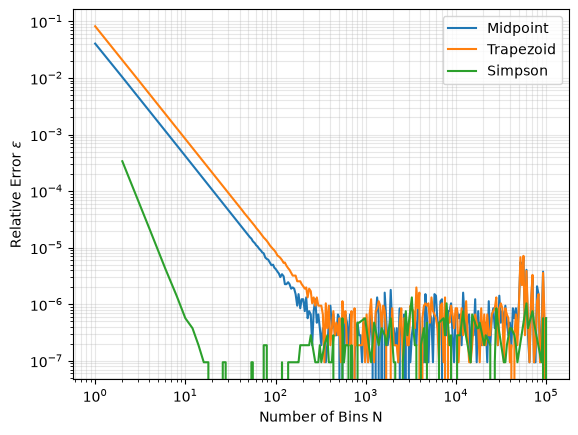

In [10]:
# (b) log-log plot of error as a function of number of bins N

plt.loglog(N, midpoint_errors, label="Midpoint")
plt.loglog(N, trapezoid_errors, label="Trapezoid")
plt.loglog(N_simpsons, simpsons_errors, label="Simpson")

plt.xlabel("Number of Bins N")
plt.ylabel(r"Relative Error $\epsilon$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

PROBLEM 3: BAO Peak

          k       P_k
0  0.000100  651.3423
1  0.000102  665.7413
2  0.000105  680.4584
3  0.000107  695.5004
4  0.000110  710.8747
(701, 2)


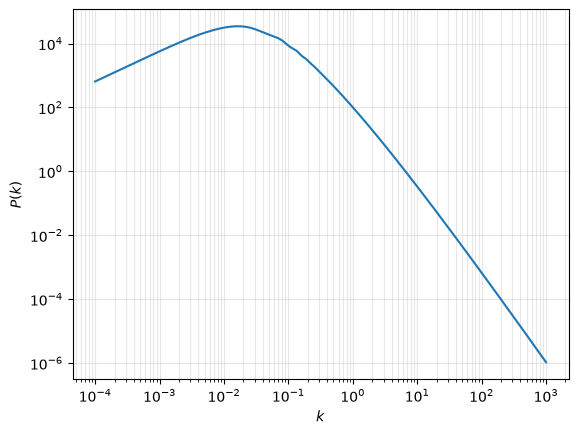

In [12]:
# plot the data file, first column is k, second column is P(k), ignore third column

power_spectrum = "/workspaces/computational_physics_homework_1/Homework 1/lcdm_z0.matter_pk"
df = pd.read_csv(power_spectrum, sep = r"\s+", header = None, usecols=[0, 1], names = ["k", "P_k"])
print(df.head())
print(df.shape)

plt.loglog(df["k"], df["P_k"])
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.grid(True, which="both", alpha=0.3)
plt.show()


In [13]:
r = np.linspace(50, 120, 1000) # Mpc/h
k = df["k"].to_numpy(dtype=np.float32)
P_k = df["P_k"].to_numpy(dtype=np.float32)

In [14]:
print(k.min(), k.max())

1e-04 1000.0


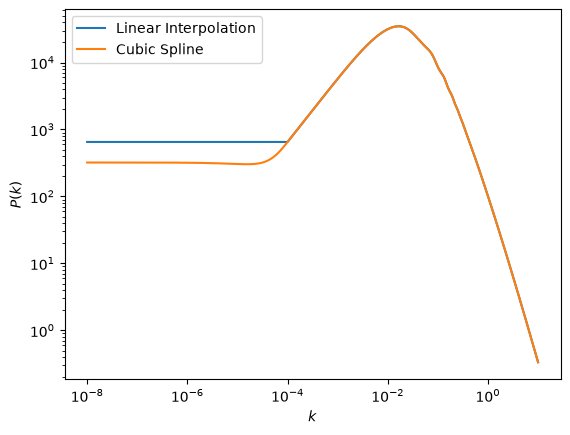

In [15]:
P_k_spline_function = CubicSpline(k, P_k, bc_type='natural')

def linear_interp(x, k, P_k):
    x = np.clip(x, k[0], k[-1])
    idx1 = np.searchsorted(k, x)
    idx1 = np.where(idx1 == 0, 1, idx1)
    idx1 = np.where(idx1 == len(k), len(k)-1, idx1)
    idx0 = idx1 - 1
    x0, x1 = k[idx0], k[idx1]
    y0, y1 = P_k[idx0], P_k[idx1]
    P_k_interp = y0 + (x - x0) * (y1 - y0) / (x1 - x0)
    return P_k_interp

def P_k_spline(k_i):
    return P_k_spline_function(k_i)

def P_k_linear(k_i):
    return linear_interp(k_i, k, P_k)

k_new = np.logspace(-8, 1, 1000, dtype=np.float64)

P_k_cubic = P_k_spline(k_new)
P_k_linear_values = P_k_linear(k_new)

plt.loglog(k_new, P_k_linear_values, label='Linear Interpolation')
plt.loglog(k_new, P_k_cubic, label='Cubic Spline')
plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.legend()
plt.show()

In [16]:
def int_linear(r):
    factor = np.float64(1) / np.float64(2 * np.pi**2)
    def integrand(k_i):
        return k_i**2 * P_k_linear(k_i) * (np.sin(k_i * r) / (k_i * r))
    integral = factor * simpsons_rule(integrand, k_new[0], k_new[-1], 1000)
    return integral

def int_spline(r):
    factor = np.float64(1) / np.float64(2 * np.pi**2)
    def integrand(k_i):
        return k_i**2 * P_k_spline(k_i) * (np.sin(k_i * r) / (k_i * r))
    integral = factor * simpsons_rule(integrand, k_new[0], k_new[-1], 1000)
    return integral

In [17]:
xi_spline = np.array([int_spline(r_i) for r_i in r])

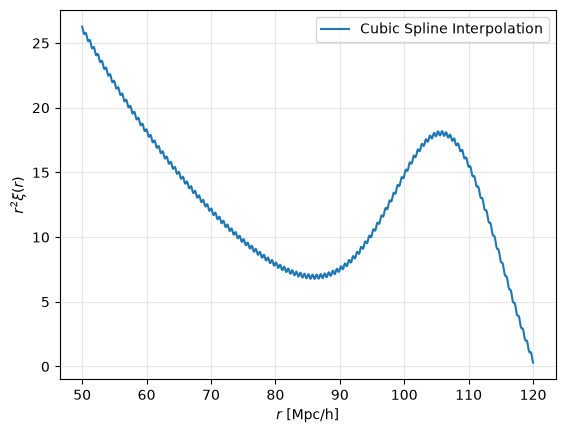

In [18]:
plt.plot(r, r**2 * xi_spline, label="Cubic Spline Interpolation")

plt.xlabel(r"$r$ [Mpc/h]")
plt.ylabel(r"$r^2 \xi(r)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

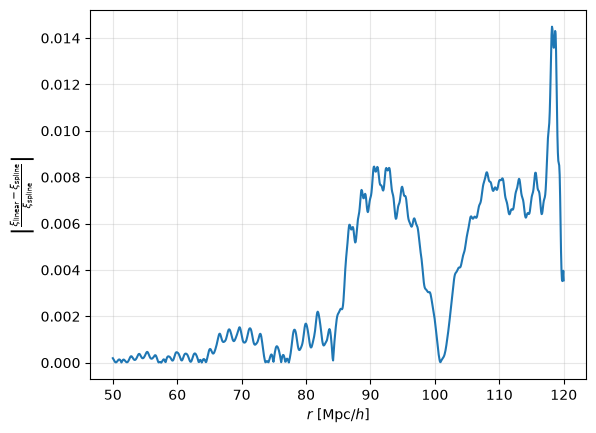

In [19]:
# extra credit: linear vs cubic spline interpolation fractional difference

xi_linear = np.array([int_linear(r_i) for r_i in r])

fractional_error = np.abs((xi_linear - xi_spline) / xi_spline)
plt.plot(r, fractional_error)
plt.xlabel(r"$r$ [Mpc/$h$]")
plt.ylabel(r"$\left|\frac{\xi_{\rm linear}-\xi_{\rm spline}}{\xi_{\rm spline}}\right|$")
plt.grid(alpha=0.3)
plt.show()

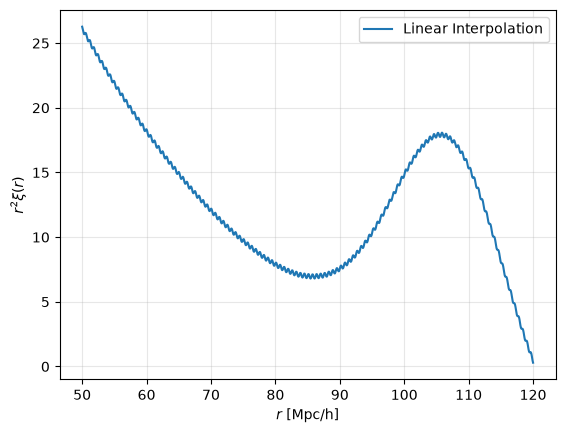

In [20]:
plt.plot(r, r**2 * xi_linear, label="Linear Interpolation")

plt.xlabel(r"$r$ [Mpc/h]")
plt.ylabel(r"$r^2 \xi(r)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()